In [1]:
import os
from TileSampling import WSITileSampler
import pandas as pd
import argparse
import natsort

parser = argparse.ArgumentParser()
parser.add_argument('--root', type= str , default = '/mnt/fileserver1_data/nfs/shared/Pathology/Prostate_Busan/', help = 'WSI data directory folder')
parser.add_argument('--output_dir', type= str , default = '/mnt/fileserver1_data/nfs/shared/Pathology/Prostate_Busan/embedded_features/coords', help = 'save directory after pre-processing')
parser.add_argument('--end', type= str , default = "svs", help = 'WSI format')
parser.add_argument('--thumbnail_level', type= int , default = -1, help = 'level of thumbnail')
parser.add_argument('--downscale_factor', type= int , default = 32, help = 'downscaling factors')
parser.add_argument('--thumbnail_dir', type= str , default = f'/mnt/fileserver1_data/nfs/shared/Pathology/Prostate_Busan/thumbnail', help = 'WSI data directory folder')
parser.add_argument('--is_normalized', type= bool , default = True, help = 'WSI data directory folder')
parser.add_argument('--original_magnification_level', type= int , default = 0, help = 'Original level of WSI magnification')

args = parser.parse_args(args=[])

In [2]:
imgList = ['/mnt/fileserver1_data/nfs/shared/Pathology/Prostate_Busan/busan_set1/DB-000020-A1.svs']
imgname = imgList[0]
print(imgname)

/mnt/fileserver1_data/nfs/shared/Pathology/Prostate_Busan/busan_set1/DB-000020-A1.svs


In [3]:
end='svs'
thumbnail_level=-1
downscale_factor=32
thumbnail_dir=None
original_magnification_level=0
is_normalized=True

In [4]:
### Load wsi
import openslide
import os
import cv2
import time
import math
import numpy as np
import matplotlib.pyplot as plt
import natsort
import tqdm

from ForegroundMasking import ForegroundMasker
from Tiling import TileSampler
from enhanceStain import get_imagej_enhanced_thumbnail
from criterion import should_apply_color_adjustment

svs_file = os.path.join(imgname) ### for BRCAS dataset
print("########################## FILE {} #####################".format(svs_file))
# print(svs_file)
slide = openslide.OpenSlide(svs_file)

### [YS] If there's no given thumbnail, we need to extract our own thumbnail with downscaling factor
### [SM] If the given thumbnail is too small adjust the thumbnail size most likely to 1000x1000 image
lv_dimensions = slide.level_dimensions

for idx in range(len(lv_dimensions)):
    x,y = lv_dimensions[-(idx+1)]
    if x*y > 1000000:
        thumbnail_level = -(idx+1)
        break


if len(slide.level_dimensions) > 1:   
    thumbnail = np.array(slide.get_thumbnail(slide.level_dimensions[thumbnail_level]))
    scaler =  int(slide.level_downsamples[thumbnail_level])
else : 
    thumbnail = np.array(
        slide.get_thumbnail( 
            (slide.level_dimensions[original_magnification_level][0]//downscale_factor,
            slide.level_dimensions[original_magnification_level][1]//downscale_factor) 
            )
        )
    scaler = int(downscale_factor)

########################## FILE /mnt/fileserver1_data/nfs/shared/Pathology/Prostate_Busan/busan_set1/DB-000020-A1.svs #####################


In [5]:
thumbnail.shape

(1083, 1875, 3)

In [6]:
# foreground,mask = self.compute_foreground_mask(thumbnail)

import os
import cv2
import numpy as np
import math
from skimage.morphology import remove_small_objects, remove_small_holes
from enhanceStain import get_imagej_enhanced_thumbnail
from criterion import should_apply_color_adjustment
from stainNorm import TCGAStainNormalizer

class ForegroundMasker:
    def __init__(self, kernel_size=(7, 7), min_hole_area=5, min_area=5, hole_area_threshold=10): 
        """
        Parameters:
            kernel_size (tuple): Kernel size for morphological operations.
            min_hole_area (int): Minimum hole area threshold for hole removal.
            min_area (int): Minimum area for regions to keep during fat removal.
            hole_area_threshold (int): Maximum size of holes to fill.
        """
        self.kernel_size = kernel_size
        self.min_hole_area = min_hole_area
        self.min_area = min_area
        self.hole_area_threshold = hole_area_threshold
        self.normalizer = TCGAStainNormalizer(output_path="inference_output")
        self.normalizer.load_template("templates/tcga_brca_template.json")

    def morphological_cleanup(self, mask):
        """Clean mask using morphological operations."""
        kernel = np.ones(self.kernel_size, np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)  # Fill small gaps
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)   # Remove noise
        mask = cv2.dilate(mask, kernel, iterations=2)           # Expand regions
        return mask

    def enhance_contrast(self, image):
        """Enhance contrast for better detection."""
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        l_enhanced = clahe.apply(l)
        return cv2.cvtColor(cv2.merge((l_enhanced, a, b)), cv2.COLOR_LAB2RGB)

    def yuv_red_filter(self, image):
        yuv = cv2.cvtColor(self.enhance_contrast(image), cv2.COLOR_RGB2YUV)
        mask = cv2.inRange(yuv, (0, 0, 140), (255, 120, 255))
        return self.morphological_cleanup(mask)

    def yuv_green_filter(self, image):
        yuv = cv2.cvtColor(self.enhance_contrast(image), cv2.COLOR_RGB2YUV)
        mask = cv2.inRange(yuv, (0, 90, 0), (255, 255, 120))
        return self.morphological_cleanup(mask)

    def yuv_blue_filter(self, image):
        yuv = cv2.cvtColor(self.enhance_contrast(image), cv2.COLOR_RGB2YUV)
        mask = cv2.inRange(yuv, (0, 130, 0), (255, 255, 120))
        return self.morphological_cleanup(mask)

    def remove_small_holes_(self, mask):
        """
        Remove small holes inside the mask.
        """
        inverted_mask = cv2.bitwise_not(mask)
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(inverted_mask, connectivity=8)
        cleaned_mask = mask.copy()
        for i in range(1, num_labels):  # Skip background (label 0)
            area = stats[i, cv2.CC_STAT_AREA]
            if area <= self.min_hole_area:
                cleaned_mask[labels == i] = 255  # Fill the small hole
        return cleaned_mask

    def get_mask(self, image, is_norm):
        # Generate YUV-based masks.
        red_mask = self.yuv_red_filter(image)
        green_mask = self.yuv_green_filter(image)
        blue_mask = self.yuv_blue_filter(image)
        yuv_mask = red_mask | green_mask | blue_mask
        cleaned_mask = self.remove_small_holes_(yuv_mask)
        mask = cv2.bitwise_not(cleaned_mask)
        #may be the technique applied to here?
        if should_apply_color_adjustment(image):
            image = np.array(get_imagej_enhanced_thumbnail(image))
        
        sample = cv2.bitwise_and(image, image, mask=mask)

        ### 이부분을 살려서 해보자
        if is_norm : 
            sample = self.normalizer.normalize_image(
                    image=sample,
                    return_image=True,
                )
        return sample, mask

    def filter_grays(self, image, tolerance=15, output_type="bool"):
        """
        Filters out gray pixels in the image.
        """
        rgb = image.astype(np.int16)
        rg_diff = np.abs(rgb[:, :, 0] - rgb[:, :, 1]) <= tolerance
        rb_diff = np.abs(rgb[:, :, 0] - rgb[:, :, 2]) <= tolerance
        gb_diff = np.abs(rgb[:, :, 1] - rgb[:, :, 2]) <= tolerance
        mask = ~(rg_diff & rb_diff & gb_diff)
        if output_type == "float":
            return mask.astype(float)
        elif output_type == "uint8":
            return (mask.astype(np.uint8) * 255)
        return mask

    def filter_green_channel(self, image, green_thresh=200, avoid_overmask=False, overmask_thresh=10, output_type="bool"):
        """
        Filters green channel to exclude highly green areas.
        """
        g_channel = image[:, :, 1]
        mask = (g_channel < green_thresh) & (g_channel > 0)
        mask_percentage = (np.sum(mask) / mask.size) * 100
        if mask_percentage >= overmask_thresh and green_thresh < 255 and not avoid_overmask:
            new_thresh = math.ceil((255 - green_thresh) / 2 + green_thresh)
            return self.filter_green_channel(image, new_thresh, avoid_overmask, overmask_thresh, output_type)
        if output_type == "float":
            return mask.astype(float)
        elif output_type == "uint8":
            return (mask.astype(np.uint8) * 255)
        return mask

    def paraffin_removal(self, image):
        """
        Removes fat-related and artifact regions from the image.
        """
        mask_not_green = self.filter_green_channel(image, green_thresh=255) ### original green_thresh : 200
        mask_not_gray = self.filter_grays(image, tolerance=5) ## original tolerance : 15
        combined_mask = mask_not_gray & mask_not_green
        combined_mask_uint8 = (combined_mask.astype(np.uint8) * 255)
        contours, _ = cv2.findContours(combined_mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cleaned_mask = np.zeros_like(combined_mask_uint8)
        for contour in contours:
            area = cv2.contourArea(contour)
            if area >= self.min_area:
                cv2.drawContours(cleaned_mask, [contour], -1, 255, thickness=cv2.FILLED)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        closed_mask = cv2.morphologyEx(cleaned_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
        return closed_mask

    def remove_background(self, img):
        """
        Removes background from the image using thresholding.
        """
        img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        img_med = cv2.medianBlur(img_hsv[:, :, 1], 7)
        _, img_otsu = cv2.threshold(img_med, 5, 255, cv2.THRESH_BINARY) ## original threshold = 20
        kernel = np.ones((4, 4), np.uint8)
        img_otsu = cv2.morphologyEx(img_otsu, cv2.MORPH_CLOSE, kernel)
        return img_otsu

    def get_foreground(self, image, is_norm):
        """
        Combines multiple processing steps to generate the final foreground mask.
        """
        foreground, mask = self.get_mask(image, is_norm)

        gray_filtered = self.paraffin_removal(foreground)
        back_filtered = self.remove_background(foreground)
        final_mask = cv2.bitwise_and(gray_filtered, back_filtered)
        return foreground, final_mask

In [7]:
masker = ForegroundMasker()
foreground,mask = masker.get_foreground(thumbnail, is_normalized)

2025-07-08 17:09:27,634 - INFO - Template loaded from: templates/tcga_brca_template.json
2025-07-08 17:09:27,635 - INFO - Template info: Created 2025-06-10T16:18:14.300234, Reference Hue=155.6
2025-07-08 17:09:28,108 - INFO - Normalizing image with shape: (1083, 1875, 3)
2025-07-08 17:09:28,145 - INFO - Normalization needed: True
2025-07-08 17:09:28,263 - INFO - Original  - Hue: 137.4, Sat: 122.8, Val: 156.4
2025-07-08 17:09:28,265 - INFO - Normalized - Hue: 94.2, Sat: 71.3, Val: 182.9
2025-07-08 17:09:28,265 - INFO - Target    - Hue: 155.6, Sat: 77.8, Val: 185.6


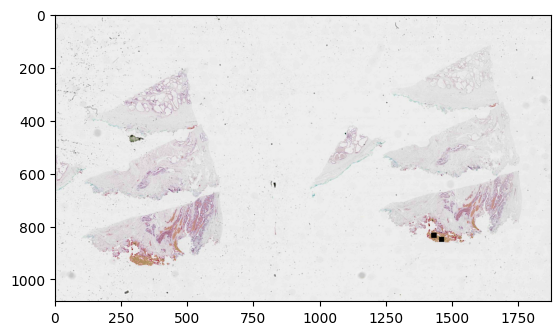

In [8]:
plt.imshow(foreground)

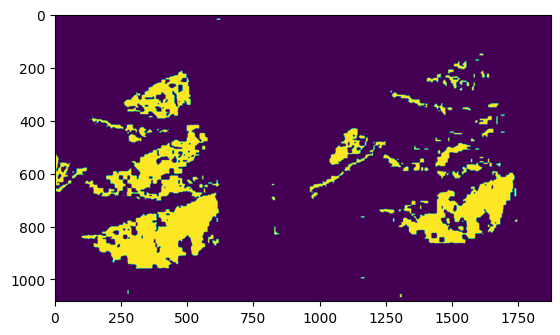

In [9]:
plt.imshow(mask)

2025-07-08 17:06:34,703 - INFO - Normalizing image with shape: (1234, 2353, 3)
2025-07-08 17:06:34,747 - INFO - Normalization needed: True
2025-07-08 17:06:34,884 - INFO - Original  - Hue: 44.5, Sat: 77.5, Val: 26.9
2025-07-08 17:06:34,886 - INFO - Normalized - Hue: 108.6, Sat: 73.1, Val: 155.3
2025-07-08 17:06:34,887 - INFO - Target    - Hue: 155.6, Sat: 77.8, Val: 185.6


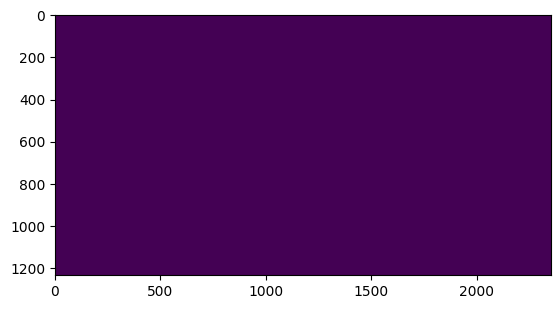

In [26]:
foreground,mask = masker.get_mask(thumbnail, is_normalized)
plt.imshow(mask)

In [99]:
gray_filtered = masker.paraffin_removal(foreground)
back_filtered = masker.remove_background(foreground)

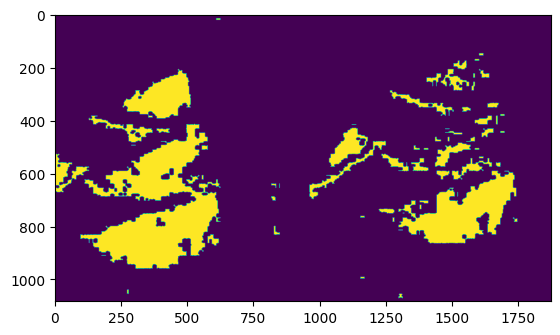

In [100]:
plt.imshow(gray_filtered)

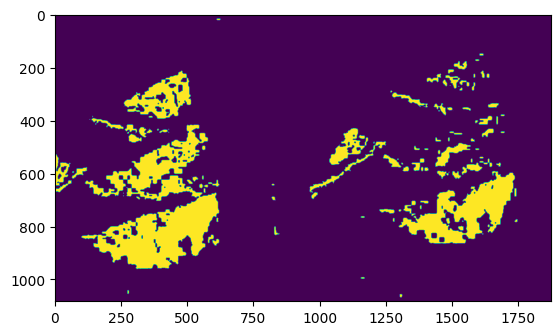

In [101]:
plt.imshow(back_filtered)

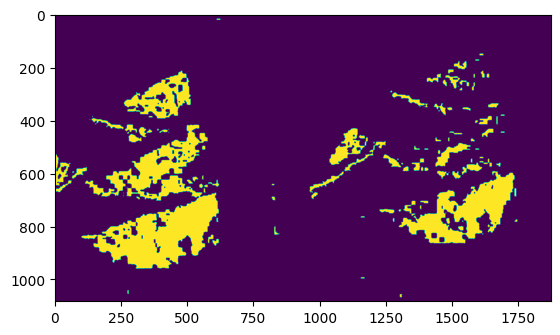

In [102]:
final_mask = cv2.bitwise_and(gray_filtered, back_filtered)
plt.imshow(final_mask)

In [10]:
'''
modified by YS, date : 2025-04-10

modification :
- adding parameters below : 
    (1) extension name parameter 'end'
    (2) thumbnail level
    (3) downscaling factor

You can check the modified parts with "[YS]"
'''

import os
import cv2
import numpy as np
import h5py
from multiprocessing import Pool

class TileSampler:
    def __init__(self, tile_size=256, overlap=0, min_tiles=5,output_dir = None, thumbnail_level=-1, downscale_factor=32,original_magnification_level=0,is_normalized=False): ### -> needs to change depending on organs, default-> BRCA : 50)
        """
        Parameters:
            tile_size (int): The desired tile size in full resolution (e.g., 256).
            overlap (float): Overlap ratio between tiles (0 means no overlap).
            min_tiles (int): Minimum number of tiles in a boundary region to be retained, needs to change depending on organs, default-> BRCA : 50 (150->50) [YS]
            thumbnail_level : Level of dimensions in thumbnail image, default : -1 [YS]
            downscale_factor : downscaling factor if there's no given thumbnail. default : 32 [YS]
        """
        self.fname = None
        self.tile_size = tile_size
        self.overlap = overlap
        self.min_tiles = min_tiles
        self.output_dir = output_dir
        self.thumbnail_level = thumbnail_level
        self.downscale_factor = downscale_factor
        self.original_magnification_level=original_magnification_level
        self.is_normalized = is_normalized
        
        self.generate_setting()
        
    def generate_setting(self) :
        output_dir = self.output_dir[:self.output_dir.rfind('/')]## removing "/final folder directories"
        settings_path = os.path.join(output_dir, "settings.txt")
        default_settings = {
        "tile_size": self.tile_size,
        "overlap": self.overlap,
        "min_tiles": self.min_tiles,
        "thumbnail_level": self.thumbnail_level,
        "original_magnification_level": self.original_magnification_level,
        "is normalized" : self.is_normalized
         }
        
        if not os.path.exists(settings_path):
            with open(settings_path, "w") as f:
                for key, value in default_settings.items():
                    f.write(f"{key} = {value}\n")
            print(f"Created new settings file: {settings_path}")
        else:
            print(f"Settings file already exists: {settings_path}")

    def extract_boundaries(self, mask):
        """
        Extract boundaries (contours) from the foreground mask.
        """
        contours, hierarchy = cv2.findContours(mask, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_NONE)
        return contours, hierarchy

    def upscale_coords(self, coords, scale_factor):
        """
        Upscale coordinates from thumbnail (mask) scale to full image scale.
        """
        return np.round(coords * scale_factor).astype(np.int32)

    def is_tile_valid(self, tile_mask, tile_coords):
        """
        Check if a tile is valid based on its centroid and border edge points.
        """
        tile_h, tile_w = tile_mask.shape
        centroid = (tile_coords[0] + tile_w // 2, tile_coords[1] + tile_h // 2)
        if tile_mask[tile_h // 2, tile_w // 2] == 0:
            return False
        top_edge = tile_mask[0, :]
        bottom_edge = tile_mask[-1, :]
        left_edge = tile_mask[:, 0]
        right_edge = tile_mask[:, -1]
        edge_count = (np.count_nonzero(top_edge) + np.count_nonzero(bottom_edge) +
                      np.count_nonzero(left_edge) + np.count_nonzero(right_edge))
        return edge_count >= 2

    def process_tile(self, args):
        """
        Worker function for processing a single tile.
        """
        x, y, tile_size, mask = args
        tile = mask[y:y+tile_size, x:x+tile_size]
        if tile.shape[0] != tile_size or tile.shape[1] != tile_size:
            return None  # Skip incomplete tiles at the edges.
        if self.is_tile_valid(tile, (x, y)):
            return (x, y)
        return None

    def sample_tiles(self, mask, tile_size):
        """
        Tile the mask using multiprocessing.
        """
        h, w = mask.shape
        stride = int(tile_size - tile_size * self.overlap)
        tasks = []
        for y in range(0, h - tile_size + 1, stride):
            for x in range(0, w - tile_size + 1, stride):
                tasks.append((x, y, tile_size, mask))
        
        with Pool() as pool:
            results = pool.map(self.process_tile, tasks)
        valid_tiles = [coord for coord in results if coord is not None]
        return valid_tiles
    def adaptive_minimum_tile_number(self,mask,scale_factor):
        """
        For each slide, determin minimum tile numbers must be clustered.
        If the sampled area is less then given threshold, will be dropped from tile sampling
        """
        foreground_pixels = np.sum(mask > 0)
        mask_tile_size = self.tile_size // scale_factor
        pixels_per_tile = mask_tile_size * mask_tile_size
        min_tiles = np.ceil(foreground_pixels / pixels_per_tile).astype(int)
        # print(min_tiles,foreground_pixels,pixels_per_tile)
        # print(mask_tile_size,self.tile_size,scale_factor)
        min_tiles = int(min_tiles * 0.0005) #less than 0.1% region will be drop
        return min_tiles

    def filter_tiles_by_boundary(self, valid_tiles, contours, tile_size):
        """
        For each tile, determine which boundary (contour) it lies in based on its centroid.
        Only retain tiles in boundaries that contain at least self.min_tiles.
        """
        clusters = {}
        for tile in valid_tiles:
            x, y = tile
            centroid = (x + tile_size / 2, y + tile_size / 2)
            for idx, contour in enumerate(contours):
                if cv2.pointPolygonTest(contour, centroid, False) >= 0:
                    clusters.setdefault(idx, []).append(tile)
                    break  # Assign to first matching contour.
        remaining_tiles = []
        for cluster in clusters.values():
            if len(cluster) >= self.min_tiles:
                remaining_tiles.extend(cluster)
        return remaining_tiles

    def save_hdf5(self, valid_tiles_full):
        """
        Save the tile coordinates and metadata to an HDF5 file.
        """
        metadata = {
            "tile_size": self.tile_size,
            "overlap": self.overlap,
            "total_tiles": len(valid_tiles_full)
        }
        with h5py.File(os.path.join(self.output_dir,f"{self.fname}.h5"), 'w') as hf:
            hf.create_dataset("tile_coords", data=np.array(valid_tiles_full))
            for key, value in metadata.items():
                hf.attrs[key] = value
        print(f"Tiling complete. Metadata and tile coordinates saved as {self.fname}.h5")

        return metadata

    def get_tile(self, image, mask, fname, scale_factor):
        """
        Main function that extracts tile coordinates from a WSI given a foreground mask.
        
        Parameters:
            slide: Whole-slide image object (e.g., from OpenSlide).
            mask (np.ndarray): Foreground mask (assumed to be derived from the thumbnail).
        
        Returns:
            valid_tiles_full (list): List of upscaled tile coordinates in full resolution.
        """
        self.fname = fname
        
        if mask is None:
            raise ValueError("Failed to load the mask image.")
        
        # Extract boundaries (contours) from the mask.
        contours, _ = self.extract_boundaries(mask)
        
        # Full-resolution dimensions.
        # full_dims = slide.level_dimensions[self.original_magnification_level]  # (width, height)
        
        # Thumbnail dimensions (mask is assumed to come from the lowest resolution level).
        ### [YS] If there's no given thumbnail, we need to extract our own thumbnail with downscaling factor
        # if len(slide.level_dimensions) > 1:  
        #     thumb_dims = slide.level_dimensions[self.thumbnail_level]
        # else : 
        #     thumb_dims = (slide.level_dimensions[self.original_magnification_level][0]//self.downscale_factor,slide.level_dimensions[self.original_magnification_level][1]//self.downscale_factor)
        # scale_factor = full_dims[0] / thumb_dims[0]  # assuming isotropic scaling

        self.min_tiles = self.adaptive_minimum_tile_number(mask,scale_factor)
        
        # Drop small contours: Full-res threshold is (tile_size^2 * min_tiles) pixels.
        # Convert this threshold to mask scale.
        threshold_area_mask = (self.tile_size**2 * self.min_tiles) / (scale_factor ** 2)
        contours = [cnt for cnt in contours if cv2.contourArea(cnt) >= threshold_area_mask]
        
        # Compute tile size in mask coordinates so that the upscaled tile is self.tile_size x self.tile_size.
        tile_size_mask = int(round(self.tile_size / scale_factor))
        
        # Sample valid tile starting coordinates at thumbnail (mask) scale.
        valid_tiles_thumb = self.sample_tiles(mask, tile_size_mask)

        
        # Filter the valid tiles by their boundaries.
        filtered_tiles_thumb = self.filter_tiles_by_boundary(valid_tiles_thumb, contours, tile_size_mask)
        
        # Upscale tile coordinates to full resolution.
        valid_tiles_full = [(int(x * scale_factor), int(y * scale_factor)) for x, y in filtered_tiles_thumb]
        
        # Save HDF5 file with metadata.
        metadata = self.save_hdf5(valid_tiles_full)
        
        return valid_tiles_full, metadata


In [11]:
args.output_dir

'/mnt/fileserver1_data/nfs/shared/Pathology/Prostate_Busan/embedded_features/coords'

In [12]:
tiler = TileSampler(
                tile_size=256, 
                overlap=0, 
                min_tiles=5,
                output_dir = args.output_dir,
                thumbnail_level=thumbnail_level,
                downscale_factor=downscale_factor,
                original_magnification_level=original_magnification_level,
                is_normalized=is_normalized
            )

Settings file already exists: /mnt/fileserver1_data/nfs/shared/Pathology/Prostate_Busan/embedded_features/settings.txt


In [13]:
coords,metadata = tiler.get_tile(slide, mask,imgname.split("/")[-1][:-4],scaler)

Tiling complete. Metadata and tile coordinates saved as DB-000020-A1.h5


In [6]:
import h5py

with h5py.File("/mnt/fileserver1_data/nfs/shared/Pathology/Prostate_Busan/embedded_features/coords/DB-000020-A1.h5", "r") as file : 
    coords = file["tile_coords"][:]

In [7]:
coords.shape

(13736, 2)

Original Size ((120032, 69316), (30008, 17329), (7502, 4332), (1875, 1083))
Thumbnail Size (1875, 1083)
Original size: (120032, 69316)
Thumbnail size: (1875, 1083)
Scale factors: x=0.015620834444148227, y=0.015624098332275377


(-0.5, 1874.5, 1082.5, -0.5)

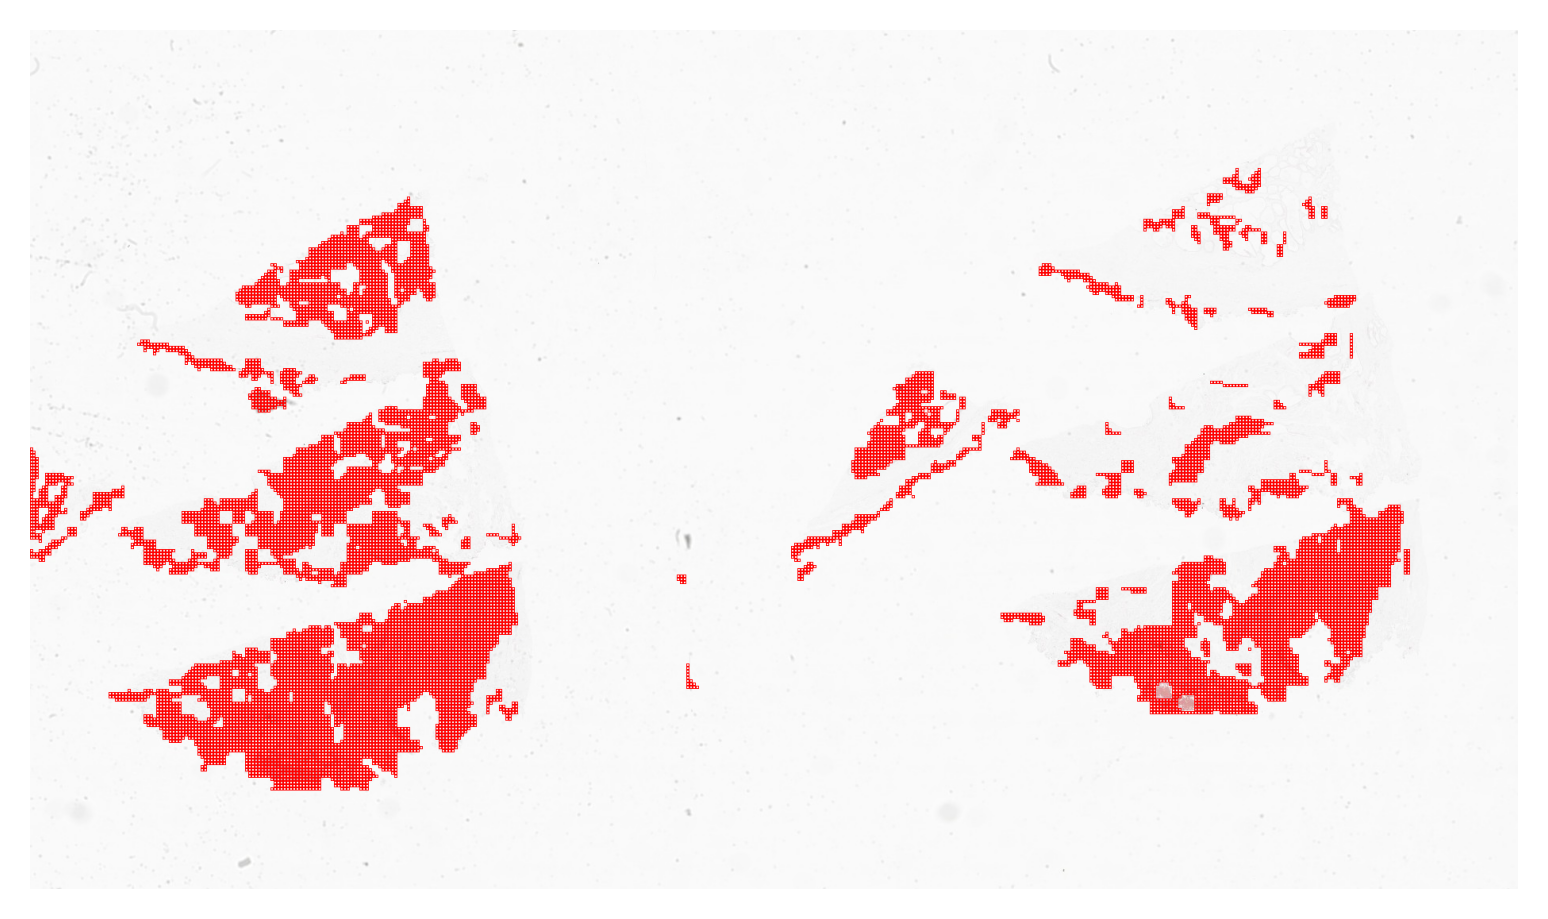

In [14]:
import os
import openslide
import h5py
from PIL import Image

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 300

tile_coords = coords

print("Original Size", slide.level_dimensions)
if len(slide.level_dimensions) > 1:
    thumbnail_size = slide.level_dimensions[args.thumbnail_level] 
else : 
    thumbnail_size = (slide.level_dimensions[0][0]//32,slide.level_dimensions[0][1]//32)
print("Thumbnail Size", thumbnail_size)
thumbnail = slide.get_thumbnail(thumbnail_size).convert("RGB")  # RGB로 변환

# 2. 원본 이미지 크기
w_orig, h_orig = slide.dimensions
print(f"Original size: ({w_orig}, {h_orig})")
print(f"Thumbnail size: {thumbnail_size}")

# 3. 축소 비율 계산
scale_x = thumbnail_size[0] / w_orig
scale_y = thumbnail_size[1] / h_orig
print(f"Scale factors: x={scale_x}, y={scale_y}")

# 4. ImageDraw 객체를 루프 밖에서 한 번만 생성
draw = ImageDraw.Draw(thumbnail)

# 5. 여러 좌표에 대해 BBox 그리기
for coord in tile_coords: 
    # 원본 좌표
    x_orig, y_orig = coord

    # 썸네일 좌표로 변환
    x_thumb = int(x_orig * scale_x)
    y_thumb = int(y_orig * scale_y)

    # BBox 크기 조정
    bbox_size = 256  # 원본 기준 크기
    bbox_width = int(bbox_size * scale_x)
    bbox_height = int(bbox_size * scale_y)

    # 좌표 및 BBox 범위 체크
    if (x_thumb < 0 or y_thumb < 0 or 
        x_thumb + bbox_width > thumbnail_size[0] or 
        y_thumb + bbox_height > thumbnail_size[1]):
        pass
    else:
        # 빨간색 사각형 그리기
        draw.rectangle(
            [(x_thumb, y_thumb), (x_thumb + bbox_width, y_thumb + bbox_height)],
            outline="red", width=1
        )

# 6. 시각화 (루프 밖에서 한 번만 호출)
plt.imshow(thumbnail)
plt.axis('off')
#plt.title("Thumbnail with Multiple BBoxes")
#plt.show()
#plt.savefig('/home/nas2_fast/Data/Pathology_project/PANDA/embedded_features/thumbnail_patch/{}.png'.format(name))